# Tools 실험

In [33]:
from AutoFineTuner.tool import codeLauncher
from AutoFineTuner.tool import codeMaker
from AutoFineTuner.tool import codeReader
from AutoFineTuner.tool import llms

# codeAnalyzer 코드 실험

In [34]:
# codeAnalyzer 코드 실험
from langchain.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import END, StateGraph, START
from typing import Annotated, List
from typing_extensions import TypedDict


In [35]:

class CodeAnalyerState(TypedDict):
    sourceCode: Annotated[str, "sourceCode"]
    modelInfo : Annotated[str, "modelInfo"]
    hyperParams: Annotated[str, "hyperParams"]
    userPrompt: Annotated[str, "userPrompt"]
    refactoredCode: Annotated[str, "refactoredCode"]

# 소스코드 기초 분석함수

In [36]:
prompt_to_reasoning_code = PromptTemplate(
    template="""
# 지시사항
소스코드에서 AI 라이브러리/모델 목적/훈련 흐름을 분석하고,
튜닝 후보 하이퍼파라미터를 제안하라.

# 소스코드
{{ sourceCode }}

# Answer
간결하게 요약하고, 근거가 되는 코드 위치(함수/클래스/라인 키워드)를 함께 제시하라.
""",
    input_variables=["sourceCode"],
    template_format="jinja2",
)

# 모델 이해하기
# basic 워크플로우로 사용.
def modelReasoning(state : CodeAnalyerState):
    sourceCode = state["sourceCode"]
    chain = (
        prompt_to_reasoning_code
        | llms.llm_list["solar-pro2"]
        | StrOutputParser()
    )
    modelInfo = chain.invoke({"sourceCode" : sourceCode})
    state["modelInfo"] = modelInfo
    return state

# result = modelReasoning({"sourceCode" : target_contents})
# print(result["modelInfo"])

# 파라미터 탐색함수

In [75]:
prompt_to_search_param = PromptTemplate(
    template="""
# 지시사항
modelInfo에서 제안하는 내용과 userPrompt의 내용을 바탕으로 파인튜닝때 적용할 하이퍼파라미터 변수들을 구체화해야한다.
예를들어, 
### modelInfo 내용의 일부
learning_rate`**: 0.01~0.3 범위에서 감소시키며 과적합 감소 테스트 (기본값 0.1)

### userPrompt의 일부
훈련시간의 여유는 충분히있어. 정확도를 우선으로 해서 모델의 성능을 반드시 개선하고싶어.
데이터셋의 크기는 이미지 대략 3600장이야. 이를 고려해서 에포크개수도 실험해줘.

### 예시 답변. 위 텍스트를 기반으로 아래와같이 구체적인 값들로 제안.
learning_rate = [0.01, 0.05, 0.10, 0.2, 0.3] # 시간이 충분함으로, 여러 학습률변수값을 제안.
epochs = [50, 100, 150, 200]    # 에포크값 실험. 데이터셋이 많지 않음으로 에포크를 크게설정.

# 소스코드
{{ sourceCode }}

# 훈련코드정보
{{ modelInfo }}

# 유저프롬프트
{{ userPrompt }}

# Answer
간결하게 요약하고, 근거가 되는 코드 위치(함수/클래스/라인 키워드)를 함께 제시하라.
""",
    input_variables=["modelInfo", "userPrompt"],
    template_format="jinja2",
)

# 하이퍼파라미터 찾기, 선정하기
def searchHyperParam(state : CodeAnalyerState):
    sourceCode = state["sourceCode"]
    modelInfo = state["modelInfo"]
    userPrompt = state["userPrompt"]
    chain = (
        prompt_to_reasoning_code
        | llms.llm_list["solar-pro2"]
        | StrOutputParser()
    )
    hyperParams = chain.invoke({"sourceCode" : sourceCode, "modelInfo":modelInfo,  "userPrompt" : userPrompt})
    state["hyperParams"] = hyperParams
    return state


## 코드리펙토링 함수

In [76]:
prompt_to_refactor = PromptTemplate(
    template="""
# 지시사항
modelInfo에서 제안하는 내용을 바탕으로 sourceCode를 리펙토링해서 인자화 해야한다.
이 리펙토링된 코드는 이후 여러 arg값을 기반으로 반복실행될것이다. 
이 질의사항에 대한 답변은 곧바로 파이썬파일로 write한다음 실제 실행하게 쓸것이다.
그럼으로 곧바로 실행가능한 코드형태로 답변을 제공해야한다.

# 필수 포함 arg
1. 훈련결과 저장 경로 (모델, 훈련결과 저장)
2. batch_size
3. epochs

# 원본 소스코드 예시
model.train(data=data_path, batch=2, epochs=10, imgsz=[1920, 1080])

# 정확한 답변 예시
parser.add_argument('epochs', tpye=int, default=10)
parser.add_argument('batch_size', tpye=int, default=2)
parser.add_argument('save_path', tpye=str, default="./outputs")
model.train(data=data_path, batch=arg.batch_size, epochs=arg.epochs, imgsz=[1920, 1080]) 

# 잘못된 답변 예시
아래는 요청하신 내용을 반영한 리팩토링된 파이썬 코드입니다. 주요 변경 사항은 다음과 같습니다:
1. argparse를 사용한 하이퍼파라미터 인자화
'''
parser.add_argument('epochs', tpye=int, default=10)
parser.add_argument('batch_size', tpye=int, default=2)
model.train(data=data_path, batch=arg.batch_size, epochs=arg.epochs, imgsz=[1920, 1080]) 
'''

# 소스코드
{{ sourceCode }}

# 훈련코드정보
{{ hyperParams }}

# 유저프롬프트
{{ userPrompt }}

# Answer
소스코드 형태로 답변제공해야함. 소스코드외의 답변은 있어선 안된다. 
""",
    input_variables=["sourceCode", "hyperParams", "userPrompt"],
    template_format="jinja2",
)

# 찾은 하이퍼파라미터가 인자화된, 리펙토링된 코드를 반환받기.
def codeRefactoring(state : CodeAnalyerState):
    sourceCode = state["sourceCode"]
    hyperParams = state["hyperParams"]
    userPrompt = state["userPrompt"]
    chain = (
        prompt_to_refactor
        | llms.llm_list["solar-pro2"]
        | StrOutputParser()
    )
    hyperParams = chain.invoke({"sourceCode" : sourceCode, "hyperParams":hyperParams,  "userPrompt" : userPrompt})
    state["refactoredCode"] = hyperParams
    return state

# result = codeRefactoring(result)
# print(result["refactoredCode"])

# 최소 실행보장 파일을 만들기위한 검사기 및 코드재작성기

In [77]:
from openai import OpenAI
import json

def parseCode(state : CodeAnalyerState):
    source_code = state["refactoredCode"]

    client = OpenAI()
    tools = [{
    "type": "function",
    "function": {
        "name": "emit_refactor",
        "description": "Return ONLY the refactored code. check if those args are cluded and if then not add those args 1.result_save_path, model_savepath 2.batch_size, 3.epochs",
        "parameters": {
        "type": "object",
        "properties": {"code": {"type":"string"}},
        "required": ["code"],
        "additionalProperties": False
        }
    }
    }]

    resp = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role":"system","content":"Return ONLY via the function call. No prose."},
        {"role":"user","content": f"Refactor for CLI hyperparams:\n{source_code}"}
    ],
    tools=tools,
    tool_choice={"type":"function","function":{"name":"emit_refactor"}}
    )
    args = json.loads(resp.choices[0].message.tool_calls[0].function.arguments)
    state["refactoredCode"] = args["code"]
    return state


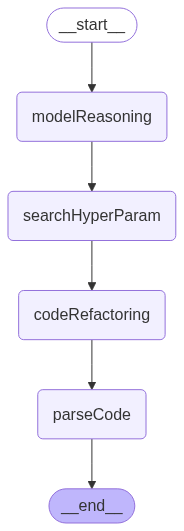

In [78]:
workflow = StateGraph(CodeAnalyerState)
workflow.add_node("modelReasoning", modelReasoning)
workflow.add_node("searchHyperParam", searchHyperParam)
workflow.add_node("codeRefactoring", codeRefactoring)
workflow.add_node("parseCode", parseCode)

workflow.add_edge(START, "modelReasoning")
workflow.add_edge("modelReasoning", "searchHyperParam")
workflow.add_edge("searchHyperParam", "codeRefactoring")
workflow.add_edge("codeRefactoring", "parseCode")
workflow.add_edge("parseCode", END)
app = workflow.compile()
app

In [79]:
# target_path = "/Users/yujin/Desktop/코딩shit/python_projects/opensource/target.py"
# target_contents = codeReader.read_text_strict(target_path)
# print(target_contents)

In [80]:
# # 각 하이퍼 파라미에터에 대한 하이퍼파라미터 선정 서브워크플로우.
# result["userPrompt"] = "데이터는 총 10만개의 문장이야. GPU를 2장사용할수있어. GPU번호는 1,2번 번호로 반드시 고정해야해. 이틀내에 작업을 완료해야해."

# result = searchHyperParam(result)

In [81]:
# print(result["hyperParams"])

## 전체 워크플로우 실험

In [82]:
# 소스파일 읽어오기.
target_path = "/Users/yujin/Desktop/코딩shit/python_projects/opensource/target.py"
target_contents = codeReader.read_text_strict(target_path)

In [83]:
state = CodeAnalyerState()
state["userPrompt"] = "데이터는 총 10만개의 문장이야. GPU를 2장사용할수있어. GPU번호는 1,2번 번호로 반드시 고정해야해. 이틀내에 작업을 완료해야해."
state['sourceCode'] = target_contents
result = app.invoke(state)
result["refactoredCode"]

'import pandas as pd\nimport argparse\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.pipeline import FeatureUnion, Pipeline\nfrom sklearn.preprocessing import FunctionTransformer\nfrom sklearn.metrics import roc_auc_score\nfrom xgboost import XGBClassifier\nimport os\nimport torch\n\ndef main(args):\n    # GPU 설정\n    os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"\n    \n    # 데이터 로드\n    train = pd.read_csv(\'./datas/train.csv\', encoding=\'utf-8-sig\')\n    test = pd.read_csv(\'./datas/test.csv\', encoding=\'utf-8-sig\')\n    X = train[[\'title\', \'full_text\']]\n    y = train[\'generated\']\n    X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)\n\n    # TF-IDF 벡터화\n    get_title = FunctionTransformer(lambda x: x[\'title\'], validate=False)\n    get_text = FunctionTransformer(lambda x: x[\'full_text\'], validate=False)\n\n    vectorizer = FeatureUnion([\n  

In [84]:
codeMaker.write_text_atomic(path_str="../output.py" , content=result["refactoredCode"])

PosixPath('/Users/yujin/Desktop/코딩shit/python_projects/opensource/output.py')

In [85]:
print(result["refactoredCode"])

import pandas as pd
import argparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import os
import torch

def main(args):
    # GPU 설정
    os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"
    
    # 데이터 로드
    train = pd.read_csv('./datas/train.csv', encoding='utf-8-sig')
    test = pd.read_csv('./datas/test.csv', encoding='utf-8-sig')
    X = train[['title', 'full_text']]
    y = train['generated']
    X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    # TF-IDF 벡터화
    get_title = FunctionTransformer(lambda x: x['title'], validate=False)
    get_text = FunctionTransformer(lambda x: x['full_text'], validate=False)

    vectorizer = FeatureUnion([
        ('title', Pipeline([('selector', get_tit

In [86]:
print(result["hyperParams"])

### 1. AI 라이브러리/모델 목적/훈련 흐름 분석
- **라이브러리**:  
  - `XGBoost` (XGBClassifier): 그래디언트 부스팅 기반 분류 모델  
  - `scikit-learn`: 전처리 (TF-IDF, 데이터 분할), 평가 (AUC)  
- **목적**:  
  텍스트(`title`, `full_text`)를 입력받아 이진 분류 (`generated` 레이블 예측)  
- **훈련 흐름**:  
  1. **데이터 로드** (라인 8~10): `train.csv`, `test.csv` 로드  
  2. **전처리**:  
     - `FunctionTransformer` (라인 15~16): `title`/`full_text` 컬럼 분리  
     - `FeatureUnion` (라인 17~23): 두 텍스트 필드를 별도 TF-IDF 벡터화 후 결합  
       - `title`: n-gram (1,2), max_features=3,000  
       - `full_text`: n-gram (1,2), max_features=10,000  
  3. **학습/검증 분할** (라인 12): `stratify=y`로 클래스 균형 유지  
  4. **모델 학습** (라인 26~27): XGBoost로 TF-IDF 피처 학습  
  5. **평가** (라인 29~30): 검증 데이터 AUC 계산  

---

### 2. 튜닝 후보 하이퍼파라미터 제안
#### (1) **TF-IDF 벡터화**  
- `ngram_range`: `(1,1)` (유니그램) 또는 `(1,3)` (3-gram 포함) 테스트  
  *근거*: 현재 `(1,2)`로 고정되어 있으나, 텍스트 특성에 따라 최적화 필요  
- `max_features`: `title` (1,000~5,000), `full_text` (5,000~15,000) 범위 조정  
  *근거*: 과적합/성능 트레이드오프 확인 필요 (라인 22, 23)  
- `TfidfVecto

In [87]:
print(result['refactoredCode'])

import pandas as pd
import argparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import os
import torch

def main(args):
    # GPU 설정
    os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"
    
    # 데이터 로드
    train = pd.read_csv('./datas/train.csv', encoding='utf-8-sig')
    test = pd.read_csv('./datas/test.csv', encoding='utf-8-sig')
    X = train[['title', 'full_text']]
    y = train['generated']
    X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    # TF-IDF 벡터화
    get_title = FunctionTransformer(lambda x: x['title'], validate=False)
    get_text = FunctionTransformer(lambda x: x['full_text'], validate=False)

    vectorizer = FeatureUnion([
        ('title', Pipeline([('selector', get_tit

# manager 코드 실험

In [ ]:
'''

run_dir = run_python(
    "/path/to/project/output.py",
    args=["--epochs=3", "--learning_rate=0.001"],
    venv_path="/path/to/project/.venv",  # 또는 venv
)

run_dir = run_python(
    "/path/to/project/output.py",
    args=["--epochs=3"],
    python_exec="/Users/yujin/.pyenv/versions/3.11.7/bin/python",
)

run_dir = run_python(
    "/path/to/project/output.py",
    args=["--epochs=3"],
    conda_env="AutoFineTuner",
    # conda_exec="/Users/yujin/miniforge3/bin/conda",  # PATH에 없으면 이렇게
)
'''

In [ ]:
# manager 코드 실험
